Korzystanie z narzędzi generatywnej AI w rozwiązywaniu zadań nie jest dozwolone

<img src="no_AI.png" alt="Use of AI allowed only when properly documented " width="100" height="100">

# Zadanie obowiązkowe [0-10] pkt

Użyj zbioru danych [Yeast](https://archive.ics.uci.edu/dataset/110/yeast) i powtórz kroki z ćwiczeń.


1. [0-2 pkt] Używając [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html), dokonaj przeszukania przestrzeni hiperparametrów kNN, zmieniając (uargumentuj wybór zakresów):
   1. liczbę sąsiadów
   1. wagę dla sąsiadów
   1. metrykę
1. [0-1.5 pkt] Do wyszukiwania dodaj miary skuteczności m.in. dokładność (*accuracy*) precyzję (*precision*), czułość (*recall*, *sensitivity*), czy też współczynnik korelacji Matthewsa (MCC). Gdzie to możliwe, dostosuj opcje miar, żeby uwzględniały niezbalansowanie zbioru
1. [0-0.5 pkt] Skomentuj wyniki uzyskane w punktach 1 i 2. Spróbuj zinterpretować wyniki
1. [0-2 pkt] Dokonaj selekcji cech, używając [SequentialFeatureSelector](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SequentialFeatureSelector.html). Zmieniaj parametr `n_features_to_select` od dwóch do pięciu. Ile cech uzyskujemy przy opcji `auto`?
1. [0-0.5 pkt] Używając [Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html), sprawdź wpływ skalowania / normalizacji na wyniki (użyj m.in. `MinMaxScaler` oraz `RobustScaler`)
1. [0-1 pkt] Skomentuj wyniki uzyskane w punktach 4 i 5
1. [0-1.5 pkt] Dla najlepszej pary `n_features_to_select=2` wyryuj obszary decyzyjne. Skomentuj wyniki
1. [0-1 pkt] Czy w świetle uzyskanych wyników, kNN jest odpowiednim klasyfikatorem do tego problemu? Uzasadnij odpowiedź
  
<span style="color:red">**Uwaga:**</span> zadania bez komentarzy i wniosków zostaną ocenione na **0 punktów**.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OrdinalEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, matthews_corrcoef, make_scorer, classification_report
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.pipeline import Pipeline

In [2]:
from ucimlrepo import fetch_ucirepo 
  
yeast = fetch_ucirepo(id=110) 
  
X = yeast.data.features 
y = yeast.data.targets 

print(yeast.metadata) 

print(yeast.variables) 


{'uci_id': 110, 'name': 'Yeast', 'repository_url': 'https://archive.ics.uci.edu/dataset/110/yeast', 'data_url': 'https://archive.ics.uci.edu/static/public/110/data.csv', 'abstract': 'Predicting the Cellular Localization Sites of Proteins', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1484, 'num_features': 8, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['localization_site'], 'index_col': ['Sequence_Name'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1991, 'last_updated': 'Sat Oct 28 2023', 'dataset_doi': '10.24432/C5KG68', 'creators': ['Kenta Nakai'], 'intro_paper': None, 'additional_info': {'summary': 'Predicted Attribute: Localization site of protein. ( non-numeric ).\r\n\r\nThe references below describe a predecessor to this dataset and its development. They also give results (not cross-validated) for classification by a rule-based expert system with that version of th

In [3]:
X.head()
y.head()

X.shape, y.shape
y['localization_site'].value_counts()

localization_site
CYT    463
NUC    429
MIT    244
ME3    163
ME2     51
ME1     44
EXC     35
VAC     30
POX     20
ERL      5
Name: count, dtype: int64

Zbiór danych Yeast zawiera 1484 obserwacje oraz 8 cech numerycznych opisujących właściwości białek. Zmienna docelowa localization_site określa lokalizację białka w komórce i ma charakter kategoryczny. Zbiór nie zawiera brakujących danych, jednak klasy są niezbalansowane. Niektóre występują znacznie rzadziej.

In [4]:
encoder = OrdinalEncoder()

y_enc = encoder.fit_transform(y[['localization_site']])
y_enc = y_enc.ravel()

erl_code = list(encoder.categories_[0]).index('ERL')

idx_to_drop = y.index[y_enc == erl_code]

X = X.drop(idx_to_drop)
y = y.drop(idx_to_drop)

y_trans = encoder.fit_transform(y[['localization_site']]).ravel()

Ze względu na małą reprezentację klasy ERL, usunąłem ją. Tak mała reprezentacja mogłaby negatywnie wpłynąć na proces uczenia się i ocenę modelu. Do identyfikacji tej klasy użyłem OrdinalEncoder, co pozwoliło na operowanie na wartościach liczbowych.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Przeskalowałem dane przy użyciu StandardScaler. Jest to istotne dla algorytmu kNN, który bazuje na odległościach między punktami. Brak skalowania mógłby spowodować dominację cech o większych wartościach.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_trans,
    stratify=y_trans,
    test_size=0.1,
    random_state=0
)

Podzieliłem dane na zbiór treningowy i testowy w proporcji 90:10. Zastosowałem stratify, aby zachować proporcje klas w obu zbiorach.

In [7]:
knn = KNeighborsClassifier()

param_grid = {
    'n_neighbors': list(range(3, 21, 2)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, average='macro'),
    "recall": make_scorer(recall_score, average='macro'),
    "mcc": make_scorer(matthews_corrcoef)
}

grid = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring=scoring,
    refit="mcc",
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X_train, y_train)

print("Najlepsze parametry:", grid.best_params_)
print("Najlepszy wynik (CV-MCC):", grid.best_score_)

y_pred = grid.predict(X_test)
print("Accuracy (test):", accuracy_score(y_test, y_pred))
print("Precision (test, macro):", precision_score(y_test, y_pred, average="macro"))
print("Recall (test, macro):", recall_score(y_test, y_pred, average="macro"))
print("MCC (test):", matthews_corrcoef(y_test, y_pred))

print(classification_report(y_test, y_pred))

Najlepsze parametry: {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'distance'}
Najlepszy wynik (CV-MCC): 0.4990636239824872
Accuracy (test): 0.581081081081081
Precision (test, macro): 0.3723697013926899
Recall (test, macro): 0.37328305808336143
MCC (test): 0.4519258088337986
              precision    recall  f1-score   support

         0.0       0.55      0.70      0.62        46
         1.0       0.50      0.25      0.33         4
         2.0       0.33      0.50      0.40         4
         3.0       0.00      0.00      0.00         5
         4.0       0.72      0.81      0.76        16
         5.0       0.62      0.52      0.57        25
         6.0       0.62      0.58      0.60        43
         7.0       0.00      0.00      0.00         2
         8.0       0.00      0.00      0.00         3

    accuracy                           0.58       148
   macro avg       0.37      0.37      0.36       148
weighted avg       0.56      0.58      0.56       148



C:\Users\Kubul\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Kubul\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Kubul\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_clas

W ramach zadania przeprowadzono optymalizację hiperparametrów klasyfikatora kNN przy użyciu GridSearchCV. Wybrałem liczbę sąsiadów z zakresu od 3 do 19 (co 2), aby uniknąć remisów i sprawdzić modele zarówno o małej liczbie sąsiadów, jak i te o większej. Sposób ważenia sąsiadów wybrałem uniform (wszyscy sąsiedzi mają ten sam wpływ) oraz distance (bliżsi sąsiedzi mają większy wpływ), dzięki czemu można sprawdzić, czy bliska odległość poprawia jakość klasyfikacji. Metryki odległości wybrałem euclidean, manhattan i minkowski, bo pozwalają one ocenić wpływ różnych sposobów mierzenia podobieństwa punktów.

W celu dokładniejszej oceny jakości modelu zastosowano kilka metryk: accuracy (ogólna skuteczność klasyfikacji), precision (średnia precyzja liczona równomiernie dla wszystkich klas), recall (średnia czułość, niezależna od liczebności klas), MCC (odporna metryka na niezbalansowanie danych, uwzględniająca wszystkie elementy macierzy pomyłek). Jako funkcję optymalizacji wybrałem MCC, gdyż najlepiej opisuje prawdziwą jakość klasyfikatora przy nierównomiernym rozkładzie klas.

Najlepsze parametry uzyskano dla metryki euklidesowej, liczby sąsiadów 15 i sposobie ważenia distance, co oznacza, że model najlepiej działa dla umiarkowanej liczby sąsiadów oraz z uwzględnieniem ważenia odległości, więc bliższe próbki mają większe znaczenie w klasyfikacji.

Uzyskane wyniki na zbiorze testowym wskazują na to, że mimo umiarkowanej dokładności ogólnej, jakość modelu dla poszczególnych klas jest niższa. Niskie wartości precision i recall sugerują problem z nierównomiernym rozpoznawaniem klas. Model lepiej sobie radzi z klasami dominującymi, a gorzej z rzadkimi. Część klas nie została w ogóle przewidziana przez model, co jest typowe dla danych niezbalansowanych oraz algorytmu kNN.

In [14]:
knn = KNeighborsClassifier(
    n_neighbors=15,
    metric='euclidean',
    weights='distance'
)

results_sfs = {}

X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

for k in range(2, 6):
    sfs = SequentialFeatureSelector(
        estimator=knn,
        n_features_to_select=k,
        direction='forward',
        scoring='matthews_corrcoef',
        cv=5,
        n_jobs=-1
    )

    sfs.fit(X_train, y_train)

    selected_features = X_train.columns[sfs.get_support()]

    print(f"\nLiczba cech: {k}")
    print("Wybrane cechy:", list(selected_features))

    X_train_sfs = sfs.transform(X_train)
    X_test_sfs = sfs.transform(X_test)

    knn.fit(X_train_sfs, y_train)
    score = knn.score(X_test_sfs, y_test)

    print("Accuracy na teście:", score)

    results_sfs[k] = selected_features


Liczba cech: 2
Wybrane cechy: ['alm', 'nuc']
Accuracy na teście: 0.43243243243243246

Liczba cech: 3
Wybrane cechy: ['alm', 'mit', 'nuc']
Accuracy na teście: 0.5405405405405406

Liczba cech: 4
Wybrane cechy: ['mcg', 'alm', 'mit', 'nuc']
Accuracy na teście: 0.5337837837837838

Liczba cech: 5
Wybrane cechy: ['mcg', 'gvh', 'alm', 'mit', 'nuc']
Accuracy na teście: 0.5945945945945946


Zastosowano metodę Sequential Feature Selector w trybie forward, zmieniając liczbę cech od 2 do 5. Najlepszy wynik uzyskano dla 5 cech (accuracy około 0.59), a przy mniejszych konfiguracjach pojawiały się już najważniejsze cechy (alm, nuc, mit), co wskazuje na to, że mają one duże znaczenie. Wraz ze wzrostem liczby cech, jakość modelu zwykle rosła, jednak nie zawsze w sposób liniowy, co może świadczyć o częściowej redundancji informacji między cechami. Przy opcji auto uzyskujemy 4 cechy. Algorytm wybrał więc taką liczbę zmiennych jako kompromis między złożonością, a skutecznością modelu.

In [ ]:
pipelines = {
    "Brak skalowania": Pipeline([
        ("knn", knn)
    ]),

    "StandardScaler": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", knn)
    ]),

    "MinMaxScaler": Pipeline([
        ("scaler", MinMaxScaler()),
        ("knn", knn)
    ]),

    "RobustScaler": Pipeline([
        ("scaler", RobustScaler()),
        ("knn", knn)
    ])
}

for name, pipeline in pipelines.items():
    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    print(f"\n{name}")
    print("Średnia accuracy (CV):", scores.mean())


Brak skalowania
Średnia accuracy (CV): 0.6145447889386387

StandardScaler
Średnia accuracy (CV): 0.6137985412970629

MinMaxScaler
Średnia accuracy (CV): 0.6085438314888345

RobustScaler
Średnia accuracy (CV): 0.6055475768071865


Porównano wpływ różnych metod skalowania danych na skuteczność klasyfikatora kNN i uzyskano bardzo zbliżone wyniki wynoszące około 0.6-0.61 accuracy. Najlepszy wynik uzyskano dla danych bez skalowania, choć różnice są niewielkie. Brak istotnej różnicy może wynikać ze specyfiki zbioru Yeast, gdzie wyniki są już względnie dobrze znormalizowane.

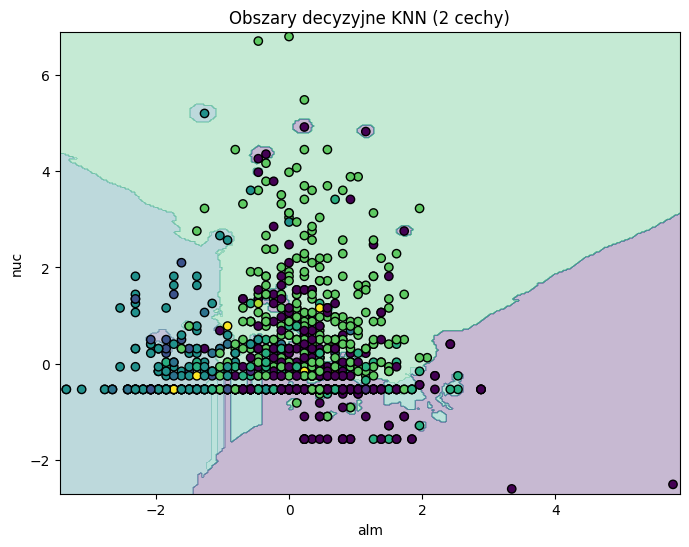

In [20]:
selected_features = ['alm', 'nuc']

X_train_2 = X_train[selected_features].values
X_test_2 = X_test[selected_features].values

knn = KNeighborsClassifier(
    n_neighbors=15,
    metric='euclidean',
    weights='distance'
)

knn.fit(X_train_2, y_train)

x_min, x_max = X_train_2[:, 0].min() - 0.1, X_train_2[:, 0].max() + 0.1
y_min, y_max = X_train_2[:, 1].min() - 0.1, X_train_2[:, 1].max() + 0.1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3)

scatter = plt.scatter(
    X_train_2[:, 0], 
    X_train_2[:, 1], 
    c=y_train, 
    edgecolor='k'
)

plt.xlabel('alm')
plt.ylabel('nuc')
plt.title('Obszary decyzyjne KNN (2 cechy)')

plt.show()

W celu wizualizacji działania kNN wykorzystano dwie najlepsze cechy wybrane przez Sequential Feature Selector (alm, nuc) i narysowano obszary decyzyjne modelu. Na wykresie widoczne są nieregularne granice decyzyjne, co jest charakterystyczne dla algorytmu kNN. W niektórych obszarach klasy nakładają się na siebie, ale model dość dobrze odwzorowuje lokalne struktury.

kNN jest umiarkowanie skutecznym algorytmem dla tego problemu. Z jednej strony osiąga dokładność około 0.6, dobrze odwzorowuje lokalne zależności w danych i nie wymaga uczenia parametrów modelu, ale ma problemy z niezbalansowanymi klasami, które występują w tym zbiorze danych. Niektóre klasy w ogóle nie są przewidywane, a w dodatku model tworzy niestabilne granice decyzyjne.

W związku z tym kNN może być użyteczny jako model bazowy, jednak do tego problemu bardziej skuteczne mogą się okazać bardziej zaawansowane metody.